# Task: Breast Cancer Diagnostic Classification

**Goal:** decide whether a breast tumour is **malignant** (cancerous) or **benign** (not cancerous) from measurements of cell nuclei taken from a digitised image of a fine needle aspirate.

**Type of problem:** binary classification.

**Dataset:** Wisconsin Diagnostic Breast Cancer (569 patients, 30 numeric features), bundled with scikit-learn. This is a learning benchmark, not a clinical tool.

**Models compared:** Logistic Regression, Decision Tree, Random Forest.

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")
os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)
RANDOM_STATE = 42
sns.set_style("whitegrid")
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve)

## 1. Load and inspect the data

In [2]:
raw = load_breast_cancer(as_frame=True)
X = raw.data
# scikit-learn codes malignant as 0 and benign as 1. We flip it so that
# 1 = malignant, because catching malignant cases is the thing we care about.
y = 1 - raw.target
print("Shape:", X.shape, "| Missing values:", int(X.isnull().sum().sum()))
print("Malignant:", int(y.sum()), "| Benign:", int((y == 0).sum()))
X.head()

Shape: (569, 30) | Missing values: 0
Malignant: 212 | Benign: 357


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


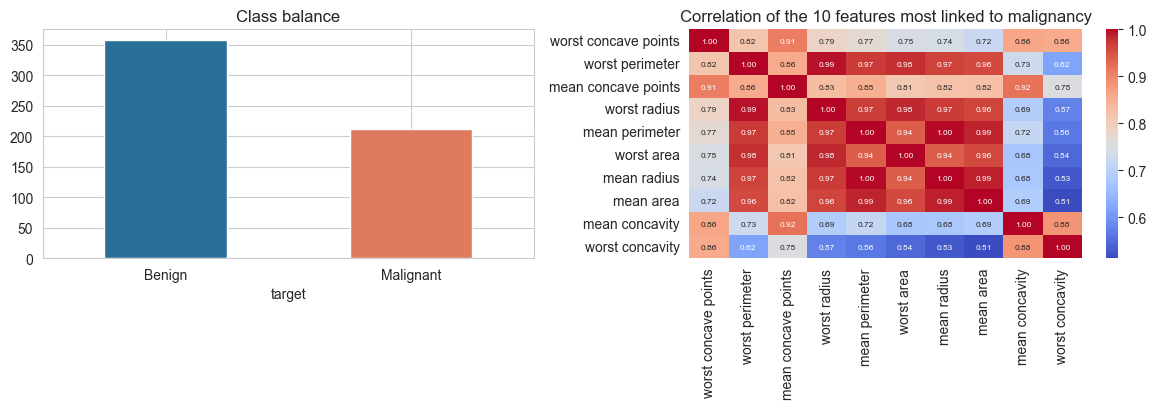

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
y.map({0: "Benign", 1: "Malignant"}).value_counts().plot.bar(ax=ax[0], color=["#2a6f97", "#e07a5f"], rot=0)
ax[0].set_title("Class balance")
top = X.corrwith(y).abs().sort_values(ascending=False).head(10).index
sns.heatmap(X[top].corr(), cmap="coolwarm", ax=ax[1], annot=True, fmt=".2f", annot_kws={"size": 6})
ax[1].set_title("Correlation of the 10 features most linked to malignancy")
plt.tight_layout(); plt.savefig("figures/task2_eda.png", dpi=150); plt.show()

## 2. Split and scale
80/20 split, **stratified** so the malignant/benign ratio is the same in train and test. Scaling puts all 30 features on a similar range, which matters for Logistic Regression.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (455, 30) Test: (114, 30)


## 3. Train and evaluate

In [5]:
models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    "Decision Tree": DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows, preds, probas = [], {}, {}
for name, m in models.items():
    m.fit(X_train, y_train)
    p = m.predict(X_test); pr = m.predict_proba(X_test)[:, 1]
    preds[name], probas[name] = p, pr
    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, p),
        "precision": precision_score(y_test, p),
        "recall": recall_score(y_test, p),
        "f1": f1_score(y_test, p),
        "roc_auc": roc_auc_score(y_test, pr),
        "cv_accuracy_mean": cross_val_score(m, X, y, cv=cv, scoring="accuracy").mean(),
    })
results = pd.DataFrame(rows).set_index("model").round(4)
results

,accuracy,precision,recall,f1,roc_auc,cv_accuracy_mean
model,,,,,,
Logistic Regression,0.9649,0.9750,0.9286,0.9512,0.9960,0.9737
Decision Tree,0.9123,0.9444,0.8095,0.8718,0.8770,0.9227
Random Forest,0.9737,1.0000,0.9286,0.9630,0.9944,0.9526


## 4. Reading the metrics
Malignant is the "positive" class.
- **Precision:** of the tumours called malignant, how many really were.
- **Recall:** of the tumours that really were malignant, how many we caught. A missed cancer is the worst error here, so recall matters most.
- **F1:** a single number balancing precision and recall.
- **ROC AUC:** how well the model separates the two classes across all thresholds (1.0 is perfect).
- **CV accuracy:** accuracy averaged over 5 different splits.

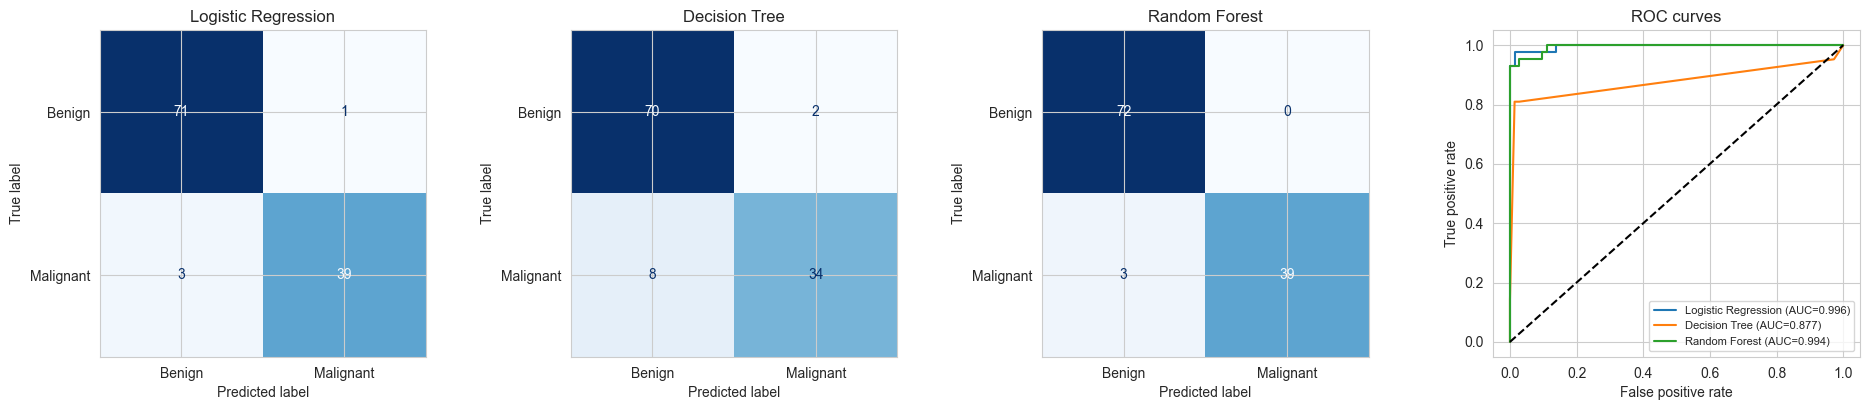

In [6]:
fig, ax = plt.subplots(1, 4, figsize=(19, 4.2))
for a, (name, p) in zip(ax[:3], preds.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, p), display_labels=["Benign", "Malignant"]).plot(ax=a, cmap="Blues", colorbar=False)
    a.set_title(name)
for name, pr in probas.items():
    fpr, tpr, _ = roc_curve(y_test, pr); ax[3].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, pr):.3f})")
ax[3].plot([0, 1], [0, 1], "k--"); ax[3].set_xlabel("False positive rate"); ax[3].set_ylabel("True positive rate")
ax[3].set_title("ROC curves"); ax[3].legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.savefig("figures/task2_results.png", dpi=150); plt.show()

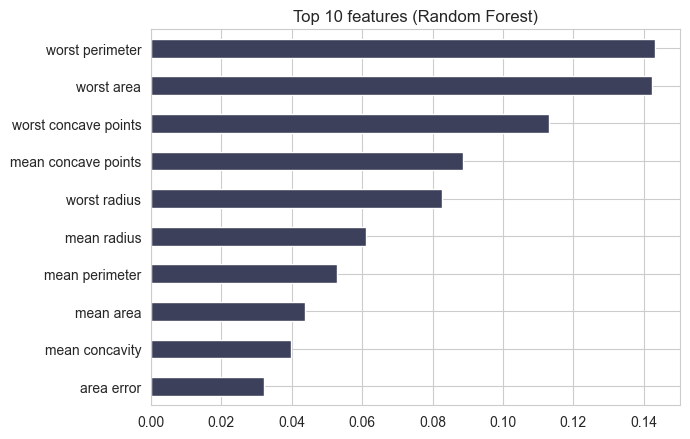

In [7]:
rf = models["Random Forest"]
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(7, 4.5)); imp[::-1].plot.barh(color="#3d405b")
plt.title("Top 10 features (Random Forest)"); plt.tight_layout()
plt.savefig("figures/task2_importance.png", dpi=150); plt.show()

In [9]:
cms = {n: confusion_matrix(y_test, p).tolist() for n, p in preds.items()}   # [[TN, FP], [FN, TP]]
summary = {
    "task": "Breast Cancer Diagnostic Classification",
    "dataset": "Wisconsin Diagnostic Breast Cancer (scikit-learn)",
    "n_rows": int(X.shape[0]), "n_features": int(X.shape[1]),
    "n_malignant": int(y.sum()), "n_benign": int((y == 0).sum()),
    "train_size": int(len(X_train)), "test_size": int(len(X_test)),
    "metrics": results.to_dict(orient="index"),
    "confusion_matrices_TN_FP_FN_TP": cms,
    "top_features_random_forest": {k: float(v) for k, v in imp.items()},
}
json.dump(summary, open("results/task2_results.json", "w"), indent=2)
print(json.dumps(summary, indent=2))

{
  "task": "Breast Cancer Diagnostic Classification",
  "dataset": "Wisconsin Diagnostic Breast Cancer (scikit-learn)",
  "n_rows": 569,
  "n_features": 30,
  "n_malignant": 212,
  "n_benign": 357,
  "train_size": 455,
  "test_size": 114,
  "metrics": {
    "Logistic Regression": {
      "accuracy": 0.9649,
      "precision": 0.975,
      "recall": 0.9286,
      "f1": 0.9512,
      "roc_auc": 0.996,
      "cv_accuracy_mean": 0.9737
    },
    "Decision Tree": {
      "accuracy": 0.9123,
      "precision": 0.9444,
      "recall": 0.8095,
      "f1": 0.8718,
      "roc_auc": 0.877,
      "cv_accuracy_mean": 0.9227
    },
    "Random Forest": {
      "accuracy": 0.9737,
      "precision": 1.0,
      "recall": 0.9286,
      "f1": 0.963,
      "roc_auc": 0.9944,
      "cv_accuracy_mean": 0.9526
    }
  },
  "confusion_matrices_TN_FP_FN_TP": {
    "Logistic Regression": [
      [
        71,
        1
      ],
      [
        3,
        39
      ]
    ],
    "Decision Tree": [
      [
     